## Introduction

This file contains code with the process of training CNN model for ASL signs recognition used in current app project.

Model is trained on dataset including signs **A-Z** and **0-9** (36 labels) obtained from here: [American Sign Language Dataset ](https://www.kaggle.com/datasets/ayuraj/asl-dataset/data)

Important to note:
- model uses Google's MobileNetV2 structure as a backbone, because of it being lightweight and optimized for performance on mobile devices with low computational cost
- model was trained on GPU using tensoflow version 2.19.0
- images used for training were resized to **224 x 224** pixels with **3** color channels and normalized to the range **0-1**
- augmentation wasn't used since our app aims for recognizing only correctly formed signs (sign direction matters)

#### TODO (updated after testing in Android Studio)
- model has to be using tensorflow 2.13.0 to work with android studio (i assume due to errors), so there is a need to either convert it to this version or train again with custom python ver and tf ver
- images rescalling outside of model's layers, i dont think its supported in tflite ;(
- current dataset doesn't include number 10 (instead has 0) which is present in the app resources, so in future updates there is a need to add new label from different dataset and train model again
- test on different test set

## Setup and dataset import

Library import

In [56]:
# kaggle dataset import
import kagglehub
# files / data manipulation
import os
import pandas as pd
import numpy as np
# visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
# model training and evaluation
import tensorflow as tf
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Rescaling
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [57]:
# visualisation setup
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.style.use('ggplot')

In [4]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dataset import from kaggle

In [6]:
import kagglehub
path = kagglehub.dataset_download("ayuraj/asl-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'asl-dataset' dataset.
Path to dataset files: /kaggle/input/asl-dataset


Setup

In [7]:
BASE_PATH = path + '/asl_dataset/asl_dataset/'
SEED = 42
IMG_SIZE = 224 # same as in app
IMG_CHANNGEL = 3
BATCH_SIZE = 32

## Data preprocessing

Divide data into train/val sets using keras preprocessing module and previously assigned values to image size and batch size

In [10]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    BASE_PATH,
    validation_split=0.2, # 80/20 train/val division
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    BASE_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 2515 files belonging to 36 classes.
Using 2012 files for training.
Found 2515 files belonging to 36 classes.
Using 503 files for validation.


Display class names in train set

In [11]:
# super important that in android code these classes are identical !!
class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


Visualise example training data

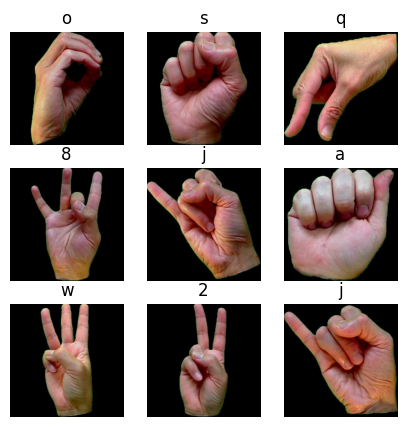

In [13]:
# https://keras.io/examples/vision/image_classification_from_scratch/
plt.figure(figsize=(5, 5))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

## Model training

Training setup - early stopping and automatic adjustment of learning rate

In [14]:
# stop training if validation loss doesnt decrease within 5 epochs
early_stoping = EarlyStopping(monitor='val_loss',
                              min_delta=0.001,
                              patience= 5,
                              restore_best_weights= True,
                              verbose = 0)
# reduce learning rate when a metric has stopped improving
reduce_learning_rate = ReduceLROnPlateau(monitor='val_accuracy',
                                         patience = 2,
                                         factor=0.5,
                                         verbose = 1)

Model structure

In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNGEL), # 224 x 224, 3 channels
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # dont change weights during training

ASL_model = Sequential([
    Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNGEL)), # standardization  1-0, move it BEFORE layers
    base_model, # MobileNetV2 as backbone
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dense(36, activation="softmax")
])

ASL_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,596 (9.26 MB)

 Trainable params: 168,612 (658.64 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Configure model training arguments

In [16]:
ASL_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model training

In [17]:
EPOCHS = 30

In [18]:
history = ASL_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=EPOCHS,
  callbacks=[early_stoping, reduce_learning_rate]
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 556ms/step - accuracy: 0.2548 - loss: 2.9604 - val_accuracy: 0.7217 - val_loss: 1.1406 - learning_rate: 0.0010
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.8114 - loss: 0.9120 - val_accuracy: 0.8588 - val_loss: 0.5764 - learning_rate: 0.0010
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8954 - loss: 0.4687 - val_accuracy: 0.8946 - val_loss: 0.4108 - learning_rate: 0.0010
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9224 - loss: 0.3332 - val_accuracy: 0.9264 - val_loss: 0.3080 - learning_rate: 0.0010
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9610 - loss: 0.2230 - val_accuracy: 0.9284 - val_loss: 0.2473 - learning_rate: 0.0010
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9654 - loss: 0.1801 - val_accuracy: 0.9145 - val_loss: 0.2632 - learning_rate: 0.0010
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9677 - loss: 0.1427 - val_a

In [61]:
def plot_training_history(history):
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']

  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs_range = range(len(history.epoch))

  plt.figure(figsize=(10, 5))
  plt.subplot(1, 2, 1)
  plt.plot(epochs_range, acc, label='Training Accuracy')
  plt.plot(epochs_range, val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')
  plt.title('Training and Validation Accuracy')

  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, loss, label='Training Loss')
  plt.plot(epochs_range, val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.title('Training and Validation Loss')
  plt.show()

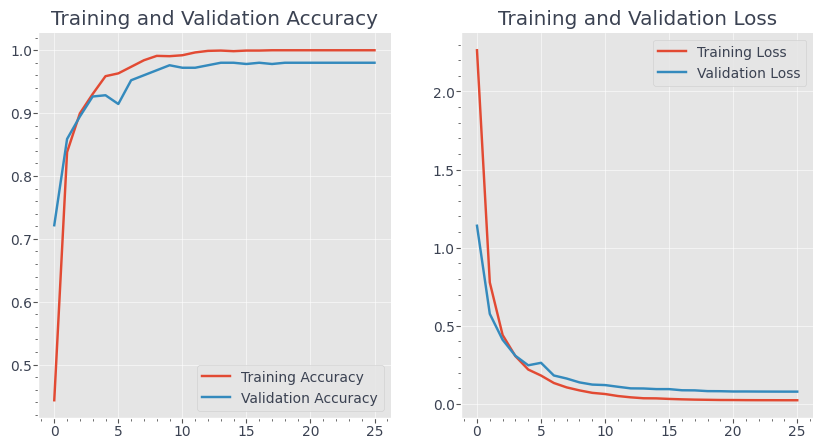

In [62]:
plot_training_history(history)

## Model evaluation

Get classification report and confusion matrix for validation set

In [63]:
def evaluate_model(val_ds, model):
    y_pred = []
    y_true = []

    for batch_images, batch_labels in val_ds:
        predictions = model.predict(batch_images, verbose=0)
        y_pred = y_pred + np.argmax(tf.nn.softmax(predictions), axis=1).tolist()
        y_true = y_true + batch_labels.numpy().tolist()

    cm = confusion_matrix(y_true, y_pred)
    print(classification_report(y_true, y_pred, target_names=class_names))

    return cm

Classification report (accuracy, presision, recall, f1-score)

In [64]:
cm = evaluate_model(val_ds, ASL_model)

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        13
           1       1.00      1.00      1.00        12
           2       1.00      0.94      0.97        17
           3       1.00      1.00      1.00         9
           4       1.00      1.00      1.00         8
           5       1.00      0.93      0.97        15
           6       0.88      0.78      0.82         9
           7       0.93      1.00      0.96        13
           8       0.93      0.93      0.93        14
           9       0.94      0.94      0.94        17
           a       1.00      1.00      1.00        13
           b       1.00      1.00      1.00        15
           c       1.00      1.00      1.00        16
           d       1.00      1.00      1.00        13
           e       1.00      1.00      1.00        14
           f       1.00      1.00      1.00        16
           g       1.00      1.00      1.00        23
           h       1.00    

Confusion matrix

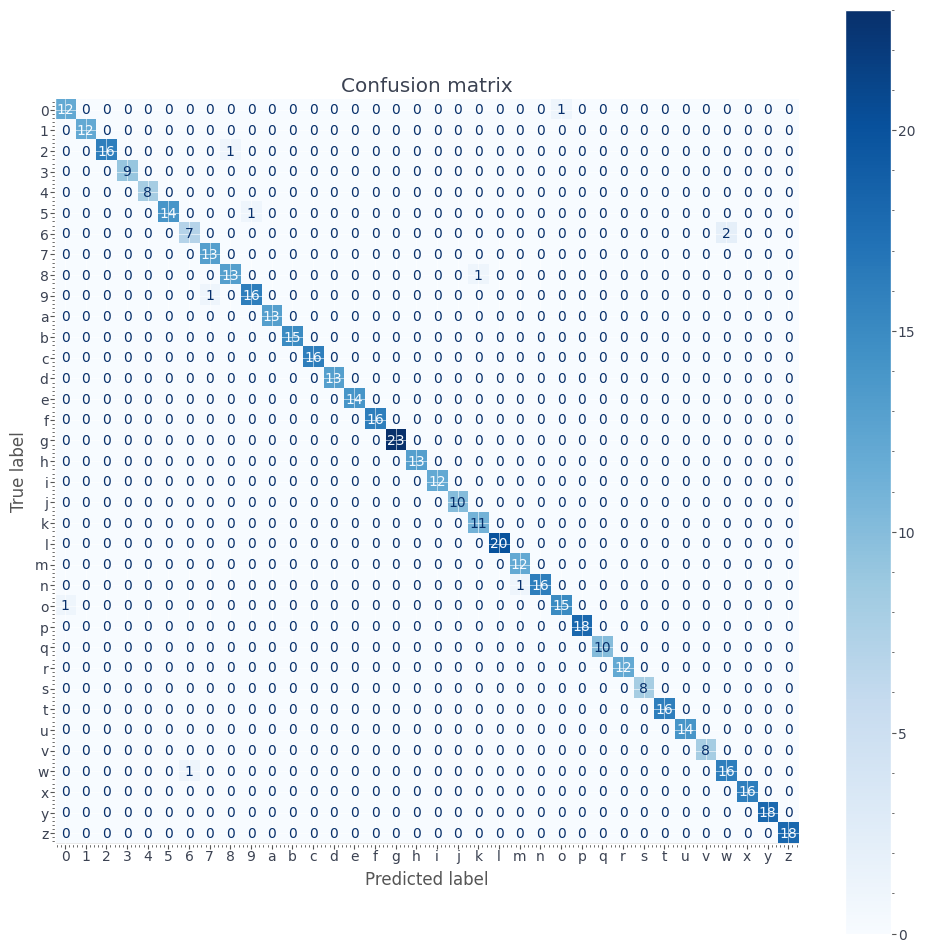

In [70]:
fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)
disp.plot(ax=ax, cmap='Blues',
          colorbar=True)
plt.title('Confusion matrix')
plt.show()

Function to check model's size after saving it to file format

In [ ]:
def check_model_size(model_file):
  # https://stackoverflow.com/questions/58513385/how-to-compare-or-measure-the-actual-size-of-models-in-tensorflow
  model_size_bytes = os.stat(model_file).st_size 
  model_size_MB = model_size_bytes / (1024 * 1024)

  print(f"Model size: {model_size_MB:.2f} MB")

Save model to keras format

In [72]:
ASL_model.save("base_model.keras")

In [73]:
check_model_size('base_model.keras')

Model size: 11.11 MB


Save model to TensorFlow Lite format

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(ASL_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # model optimalization for android
# https://stackoverflow.com/questions/71967616/convert-tensorflow-keras-python-model-to-android-tflite-model
tflite_quant_model = converter.convert()

with open('model_ASL.tflite', 'wb') as f: # replace this path with android studio assets path, im pasting
                                          # model there manually because im working on google colab and im lazy lolo
  f.write(tflite_quant_model)

In [75]:
check_model_size('model_ASL.tflite')

Model size: 2.55 MB
